In [1]:
! pip install torch>=2.0.0 torchvision>=0.15.0 numpy>=1.23.0 matplotlib>=3.7.0 scikit-learn>=1.2.0 thop>=0.1.1.post2209072238


In [5]:
! pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=f86d741d1bfa8beffbca82e88b825d593b4f0153cee360acd94a37f620e74a41
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=ba6b5a3487bf069df1de8f8df86c640a5babfcb36c5e4c28917aa6583de0e6ef
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [6]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn import svm
from sklearn.metrics import accuracy_score
import numpy as np
import time
from tqdm import tqdm
from fvcore.nn import FlopCountAnalysis


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True
print("device:", device)

device: cuda


In [8]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch

def get_dataloaders(dataset_name="MNIST", batch_size=16):
    # Use GPU optimizations only if CUDA is available
    pin = torch.cuda.is_available()
    workers = 2 if torch.cuda.is_available() else 0

    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),
                             (0.5, 0.5, 0.5))
    ])

    if dataset_name == "MNIST":
        dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
    elif dataset_name == "FashionMNIST":
        dataset = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
    else:
        raise ValueError("dataset_name must be 'MNIST' or 'FashionMNIST'")

    # 70-10-20 split
    train_size = int(0.7 * len(dataset))
    val_size = int(0.1 * len(dataset))
    test_size = len(dataset) - train_size - val_size

    train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True, pin_memory=pin, num_workers=workers)
    val_loader   = DataLoader(val_set, batch_size=batch_size,
                              shuffle=False, pin_memory=pin, num_workers=workers)
    test_loader  = DataLoader(test_set, batch_size=batch_size,
                              shuffle=False, pin_memory=pin, num_workers=workers)

    return train_loader, val_loader, test_loader


In [10]:
def print_dataloader_info(dataset_name):
    train_loader, val_loader, test_loader = get_dataloaders(
        dataset_name=dataset_name,
        batch_size=16
    )

    print(f"\n===== {dataset_name} DataLoader Info =====")
    print("Train batches:", len(train_loader))
    print("Validation batches:", len(val_loader))
    print("Test batches:", len(test_loader))

    # Inspect one batch
    images, labels = next(iter(train_loader))
    print("Batch image shape:", images.shape)   # Expected: [16, 3, 224, 224]
    print("Batch label shape:", labels.shape)   # Expected: [16]

# Print for both datasets
print_dataloader_info("MNIST")
print_dataloader_info("FashionMNIST")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


===== MNIST DataLoader Info =====
Train batches: 2625
Validation batches: 375
Test batches: 750


Batch image shape: torch.Size([16, 3, 32, 32])
Batch label shape: torch.Size([16])


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.91MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.4MB/s]


===== FashionMNIST DataLoader Info =====
Train batches: 2625
Validation batches: 375
Test batches: 750


Batch image shape: torch.Size([16, 3, 32, 32])
Batch label shape: torch.Size([16])


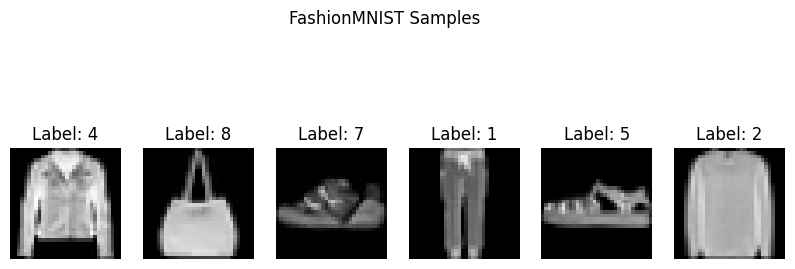

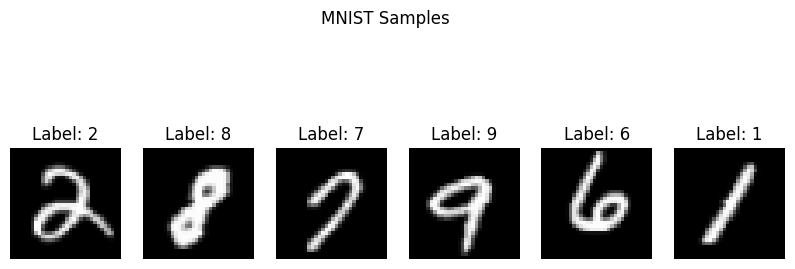

In [12]:
import matplotlib.pyplot as plt

def show_images(images, labels, title, num_images=6):
    images = images[:num_images]
    labels = labels[:num_images]

    # Convert from [B, 3, 224, 224] \u2192 [B, 224, 224, 3]
    images = images.permute(0, 2, 3, 1)

    # Denormalize images for correct display (assuming normalized to [-1, 1])
    images = (images * 0.5) + 0.5 # Revert normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

    plt.figure(figsize=(10, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

# Get data loaders for FashionMNIST
fashion_train_loader, _, _ = get_dataloaders(dataset_name="FashionMNIST", batch_size=16)
fashion_images, fashion_labels = next(iter(fashion_train_loader))
show_images(fashion_images, fashion_labels, title="FashionMNIST Samples")

# Get data loaders for MNIST
mnist_train_loader, _, _ = get_dataloaders(dataset_name="MNIST", batch_size=16)
mnist_images, mnist_labels = next(iter(mnist_train_loader))
show_images(mnist_images, mnist_labels, title="MNIST Samples")

In [13]:
def train_model(model, train_loader, val_loader, optimizer, epochs=3, device=device, use_amp=True):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)

    # Enable cuDNN autotuner (major speedup on GPU)
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True

    scaler = torch.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))

    train_losses, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, total_samples = 0.0, 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=(use_amp and device.type == "cuda")
            ):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

        avg_loss = running_loss / total_samples
        train_losses.append(avg_loss)

        # -------- Validation --------
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = 100 * correct / total
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_accs


def evaluate_model(model, test_loader, device=device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


In [15]:
import pandas as pd
import torchvision.models as models
import torch.optim as optim

def run_all_experiments(dataset="MNIST", epochs=5, device=device):
    experiments = [
        (16, "SGD", 0.001),
        (16, "SGD", 0.0001),
        (16, "Adam", 0.001),
        (16, "Adam", 0.0001),
        (32, "SGD", 0.001),
        (32, "SGD", 0.0001),
        (32, "Adam", 0.001),
        (32, "Adam", 0.0001),
    ]

    results = []

    for batch_size, optimizer_type, lr in experiments:
        print(f"\nRunning: BS={batch_size}, OPT={optimizer_type}, LR={lr}")

        train_loader, val_loader, test_loader = get_dataloaders(dataset, batch_size)

        for model_name in ["resnet18", "resnet50"]:

            print(f"Training {model_name}")

            # No pretrained weights
            if model_name == "resnet18":
                model = models.resnet18(weights=None)
            else:
                model = models.resnet50(weights=None)

            model.fc = nn.Linear(model.fc.in_features, 10)

            optimizer = (
                optim.SGD(model.parameters(), lr=lr)
                if optimizer_type == "SGD"
                else optim.Adam(model.parameters(), lr=lr)
            )

            # Train on device
            losses, accs = train_model(
                model,
                train_loader,
                val_loader,
                optimizer,
                epochs=epochs,
                device=device
            )


            # Evaluate on test set
            test_acc = evaluate_model(model, test_loader, device=device)

            print(f"Test Accuracy ({model_name}): {test_acc:.2f}%")

            results.append({
                "Batch Size": batch_size,
                "Optimizer": optimizer_type,
                "Learning Rate": lr,
                "Model": model_name,
                "Test Accuracy (%)": round(test_acc, 2)
            })

    return pd.DataFrame(results)




In [16]:
# MNIST Dataset
df = run_all_experiments(dataset="MNIST", epochs=3, device=device)
df.to_csv("final_results.csv", index=False)


Running: BS=16, OPT=SGD, LR=0.001
Training resnet18
Epoch [1/3] | Loss: 0.3404 | Val Acc: 96.97%
Epoch [2/3] | Loss: 0.1158 | Val Acc: 97.65%
Epoch [3/3] | Loss: 0.0797 | Val Acc: 98.37%
Test Accuracy (resnet18): 98.43%
Training resnet50
Epoch [1/3] | Loss: 0.9046 | Val Acc: 92.52%
Epoch [2/3] | Loss: 0.2691 | Val Acc: 95.70%
Epoch [3/3] | Loss: 0.1731 | Val Acc: 96.95%
Test Accuracy (resnet50): 96.94%

Running: BS=16, OPT=SGD, LR=0.0001
Training resnet18
Epoch [1/3] | Loss: 1.0842 | Val Acc: 90.63%
Epoch [2/3] | Loss: 0.4223 | Val Acc: 94.33%
Epoch [3/3] | Loss: 0.2925 | Val Acc: 95.48%
Test Accuracy (resnet18): 94.78%
Training resnet50
Epoch [1/3] | Loss: 2.3080 | Val Acc: 25.50%
Epoch [2/3] | Loss: 1.8940 | Val Acc: 46.48%
Epoch [3/3] | Loss: 1.3479 | Val Acc: 68.67%
Test Accuracy (resnet50): 67.26%

Running: BS=16, OPT=Adam, LR=0.001
Training resnet18
Epoch [1/3] | Loss: 0.2059 | Val Acc: 97.80%
Epoch [2/3] | Loss: 0.0979 | Val Acc: 97.73%
Epoch [3/3] | Loss: 0.0745 | Val Acc: 98.

In [17]:
# FashionMNIST Dataset
df = run_all_experiments(dataset="FashionMNIST", epochs=3, device=device)
df.to_csv("final_results.csv", index=False)


Running: BS=16, OPT=SGD, LR=0.001
Training resnet18
Epoch [1/3] | Loss: 0.6487 | Val Acc: 85.22%
Epoch [2/3] | Loss: 0.4254 | Val Acc: 87.28%
Epoch [3/3] | Loss: 0.3639 | Val Acc: 88.03%
Test Accuracy (resnet18): 87.83%
Training resnet50
Epoch [1/3] | Loss: 1.0763 | Val Acc: 74.78%
Epoch [2/3] | Loss: 0.6926 | Val Acc: 79.38%
Epoch [3/3] | Loss: 0.5974 | Val Acc: 81.53%
Test Accuracy (resnet50): 81.68%

Running: BS=16, OPT=SGD, LR=0.0001
Training resnet18
Epoch [1/3] | Loss: 1.1864 | Val Acc: 76.58%
Epoch [2/3] | Loss: 0.6977 | Val Acc: 80.30%
Epoch [3/3] | Loss: 0.5870 | Val Acc: 81.88%
Test Accuracy (resnet18): 82.49%
Training resnet50
Epoch [1/3] | Loss: 2.1329 | Val Acc: 38.87%
Epoch [2/3] | Loss: 1.5016 | Val Acc: 57.10%
Epoch [3/3] | Loss: 1.1333 | Val Acc: 66.40%
Test Accuracy (resnet50): 66.20%

Running: BS=16, OPT=Adam, LR=0.001
Training resnet18
Epoch [1/3] | Loss: 0.5363 | Val Acc: 87.18%
Epoch [2/3] | Loss: 0.3757 | Val Acc: 86.97%
Epoch [3/3] | Loss: 0.3344 | Val Acc: 88.